In [13]:
import os
import operator
from typing import TypedDict, List, Annotated, Literal
from pathlib import Path
from dotenv import load_dotenv
from pydantic import BaseModel, Field

from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.output_parsers import JsonOutputParser
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

# Load your token from .env
load_dotenv()

llm_endpoint = HuggingFaceEndpoint(
    repo_id="HuggingFaceH4/zephyr-7b-beta",
    task="text-generation",
    max_new_tokens=2048,
    do_sample=False,
)
llm = ChatHuggingFace(llm=llm_endpoint)


In [24]:
class Task(BaseModel):
    id: int
    title: str
    goal: str = "" # Default to empty if missing
    bullets: List[str] = [] # Default to empty list if missing
    target_words: int = 200 # Default if missing
    section_type: str = "core" # Default if missing


In [25]:
class Plan(BaseModel):
    blog_title: str
    audience: str = Field(..., description="Who this blog is for.")
    tone: str = Field(..., description="Writing tone (e.g., practical, crisp).")
    tasks: List[Task]

In [26]:
class State(TypedDict):
    topic: str
    plan: Plan
    sections: Annotated[List[str], operator.add]  # reducer concatenates worker outputs
    final: str

In [27]:
def orchestrator(state: State) -> dict:
    import json
    import ast
    import re
    
    prompt = (
        "You are a senior technical writer. Create a 5-section blog plan.\n"
        "You MUST include these 6 fields for EVERY task: id, title, goal, bullets, target_words, section_type.\n\n"
        "FORMAT EXAMPLE (Follow this exactly!):\n"
        "{\n"
        "  \"blog_title\": \"Self Attention Guide\",\n"
        "  \"audience\": \"Developers\",\n"
        "  \"tone\": \"Technical\",\n"
        "  \"tasks\": [\n"
        "    {\n"
        "      \"id\": 1,\n"
        "      \"title\": \"Introduction\",\n"
        "      \"goal\": \"Explain the core problem\",\n"
        "      \"bullets\": [\"Context\", \"Definitions\", \"Overview\"],\n"
        "      \"target_words\": 150,\n"
        "      \"section_type\": \"intro\"\n"
        "    }\n"
        "  ]\n"
        "}\n\n"
        f"TOPIC: {state['topic']}"
    )

    response = llm.invoke([HumanMessage(content=prompt)])
    content = response.content.strip()
    
    # Extract JSON
    match = re.search(r'\{.*\}', content, re.DOTALL)
    if not match:
        print("❌ No JSON found")
        return {"plan": Plan(blog_title="Error", audience="Devs", tone="Tech", tasks=[])}
    
    clean_content = match.group()

    try:
        # Try Strategy A & B
        try:
            plan_dict = json.loads(clean_content)
        except:
            plan_dict = ast.literal_eval(clean_content)
            
        plan = Plan(**plan_dict)
        print("✅ Plan validated and accepted!")
        return {"plan": plan}
    except Exception as e:
        print(f"❌ Validation failed: {e}")
        # Return a simple fallback if AI messes up
        return {"plan": Plan(blog_title="Self Attention Blog", audience="Developers", tone="Technical", 
                             tasks=[Task(id=1, title="What is Self Attention?", goal="Define it", bullets=["Q,K,V", "Math", "History"])])}


In [28]:
def fanout(state: State):
    return [
        Send(
            "worker",
            {"task": task, "topic": state["topic"], "plan": state["plan"]},
        )
        for task in state["plan"].tasks
    ]

In [29]:
def worker(payload: dict) -> dict:

    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    bullets_text = "\n- " + "\n- ".join(task.bullets)

    section_md = llm.invoke(
        [
            SystemMessage(
    content=(
        "You are a senior technical writer and developer advocate. Write ONE section of a technical blog post in Markdown.\n\n"
        "Hard constraints:\n"
        "- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).\n"
        "- Stay close to the Target words (±15%).\n"
        "- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).\n\n"
        "Technical quality bar:\n"
        "- Be precise and implementation-oriented (developers should be able to apply it).\n"
        "- Prefer concrete details over abstractions: APIs, data structures, protocols, and exact terms.\n"
        "- When relevant, include at least one of:\n"
        "  * a small code snippet (minimal, correct, and idiomatic)\n"
        "  * a tiny example input/output\n"
        "  * a checklist of steps\n"
        "  * a diagram described in text (e.g., 'Flow: A -> B -> C')\n"
        "- Explain trade-offs briefly (performance, cost, complexity, reliability).\n"
        "- Call out edge cases / failure modes and what to do about them.\n"
        "- If you mention a best practice, add the 'why' in one sentence.\n\n"
        "Markdown style:\n"
        "- Start with a '## <Section Title>' heading.\n"
        "- Use short paragraphs, bullet lists where helpful, and code fences for code.\n"
        "- Avoid fluff. Avoid marketing language.\n"
        "- If you include code, keep it focused on the bullet being addressed.\n"
    )
)
,
            HumanMessage(
                content=(
                    f"Blog: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Section type: {task.section_type}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Bullets:{bullets_text}\n"
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}




In [30]:
def reducer(state: State) -> dict:

    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()
    
    final_md = f"# {title}\n\n{body}\n"

    # Save to file
    filename = "".join(c if c.isalnum() or c in (" ", "_", "-") else "" for c in title)
    filename = filename.strip().lower().replace(" ", "_") + ".md"
    Path(filename).write_text(final_md, encoding="utf-8")

    return {"final": final_md}


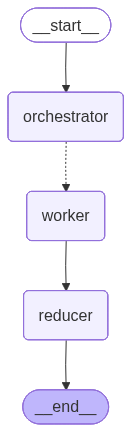

In [31]:
# -----------------------------
# 5) Graph
# -----------------------------
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

app

In [32]:
out = app.invoke({"topic": "Write a blog on Self Attention", "sections": []})


✅ Plan validated and accepted!


In [33]:
print(out["final"])

# Self Attention Guide for Developers

## How to Improve Yourself Through Self-Attention: The Basics

Self-attention has become increasingly popular in the NLP community in recent years due to its ability to learn contextual representations of language without the need for external memory mechanisms like recurrence, making it naturally scalable for long sequences. It is a relatively new technique with a notable impact on the field. But how do you implement it yourself? This guide is designed for developers looking to add self-attention to their NLP stack. In this section, we'll explain what self-attention is, what it does differently than other NLP techniques, and the reasoning behind its architecture. We'll start with definitions to build a shared understanding before jumping into implementation details.

Self-attention, also known as scaled dot-product attention, is a mechanism that allows a model to attend, or selectively focus, to different positions in a sequence to compute its ou